In [146]:


import networkx as nx
import random
from sklearn.metrics import precision_recall_curve, auc
import matplotlib.pyplot as plt

In [147]:
#Get the graph
graph2 = nx.read_graphml("./graphs/groupsGraph.graphml")
graph = nx.dorogovtsev_goltsev_mendes_graph(7)
#Get the edges and split into G_training and G_test
k = 60
edgesFull = list(graph.edges())
testEdges = random.sample(edgesFull, k) #Take 15% of edges away
trainingEdges = list(set(edgesFull) - set(testEdges))

#Need to add random edges

G_training = graph.copy()
G_training.remove_edges_from(testEdges)
G_testing = graph.copy()
G_testing.remove_edges_from(trainingEdges)


In [148]:
pred = nx.adamic_adar_index(G_training)

#need to sort the list of tuples based on the last value
sortedPred = sorted(pred, key= lambda x:x[2], reverse=True)
topPredictions = sortedPred[0:k]
topPredictionsLinks = [(k, v) for k,v,n in topPredictions]

print(topPredictions[50])

(30, 1042, 1.2352458628142324)


In [149]:
print(type(topPredictionsLinks[0]))
print(type(testEdges[0]))

<class 'tuple'>
<class 'tuple'>


In [150]:
#Figure out precision and recall. This is the metric at K
TP = list(set(topPredictionsLinks) & set(testEdges))
print(f"The TP: {len(TP)}")
Negatives = nx.complete_graph(G_testing.nodes())
#Remove the edges that actually exist
Negatives.remove_edges_from(testEdges)
Negatives.remove_edges_from(trainingEdges)
FN = list(set(testEdges).difference(set(topPredictionsLinks)))
print(f"FN: {len(FN)}")
FP = list(set(topPredictionsLinks) & (set(Negatives.edges())))
print(f"FP: {len(FP)}")


Recall = len(TP)/(len(TP)+len(FN))
Precision = len(TP)/(len(TP)+len(FP))

print(f"The Precision is: {Precision} and the Recall is: {Recall}")

The TP: 23
FN: 37
FP: 37
The Precision is: 0.38333333333333336 and the Recall is: 0.38333333333333336


In [ ]:
# #Let's try a different way
# y_true = list()
# y_pred = list()
# for a,b,c in topPredictions:
#
#
#     if (a,b) in set(testEdges) or (b,a) in set(testEdges):
#         y_true.append(1)
#         y_pred.append(c)
#         print("There's a positive")
#     else:
#         y_true.append(0)
#         y_pred.append(c)
#
# #Have the y_true and y_red
# #Need to calculate the precision and recall at each stage
# for index in range(len(y_true)):
#

In [151]:
#Let's try a different way
y_true = list()
y_pred = list()
for a,b,c in topPredictions:


    if (a,b) in set(testEdges) or (b,a) in set(testEdges):
        y_true.append(1)
        y_pred.append(c)
        print("There's a positive")
    else:
        y_true.append(0)
        y_pred.append(c)
print(y_true)

precision, recall, thresholds = precision_recall_curve(y_true,y_pred)
aupr_score = auc(recall, precision)



There's a positive
There's a positive
There's a positive
There's a positive
There's a positive
There's a positive
There's a positive
There's a positive
There's a positive
There's a positive
There's a positive
There's a positive
There's a positive
There's a positive
There's a positive
There's a positive
There's a positive
There's a positive
There's a positive
There's a positive
There's a positive
There's a positive
There's a positive
[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]


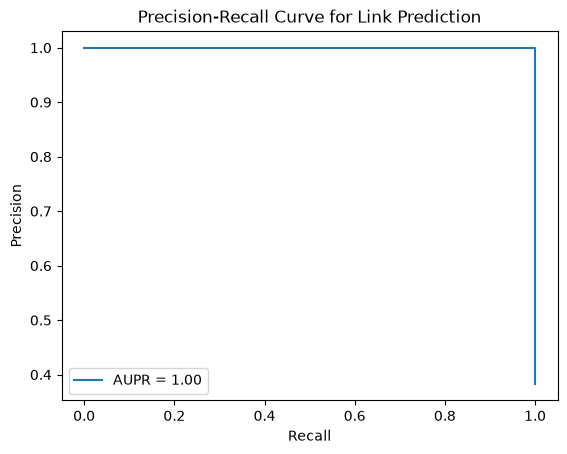

In [152]:

plt.plot(recall, precision, label=f'AUPR = {aupr_score:.2f}')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve for Link Prediction')
plt.legend()
plt.show()
